# Fixed-roster composition scenarios

Leo and Charles • 6 October 2026

The notebook is your user interface. Each scenario tuple selects
team count, roster size, and repetition count. CHANCE_RULE chooses one, seats
or both for the whole list; TALENT_DISTRIBUTION chooses the talent law. Run All applies the cells to the
whole selected list. Homophily supplies the only attachment preference.
Charles controls scientific execution; Leo prepares code and small checks.

The starting pair retains 100 teams of 20 and 30 assignments at each rho.
Population size is calculated as J*r for every tuple. Variable realized roster
sizes have a separate uncapped section below and are not controlled by these tuples.


In [1]:
from pathlib import Path
import json
import sys
import importlib

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'README_START_HERE.md').is_file():
    raise RuntimeError('Start Jupyter in lg_exploration/ or its notebooks/ folder.')
if str(PROJECT_ROOT / 'code') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'code'))
# Refresh local helpers when rerunning after notebook/code updates.
importlib.invalidate_caches()
import lg_composition.talent as _talent
import lg_composition.scenarios as _scenarios
import lg_composition.scenario_plots as _scenario_plots
for _module in (_talent, _scenarios, _scenario_plots):
    importlib.reload(_module)
from lg_composition.scenarios import Batch, export_batch, run_batch, ready_scenarios
from lg_composition.scenario_plots import (
    plot_scenario, plot_comparisons, plot_player_distribution, unique_population_scenarios,
)

# Set True when YOU want Run All to execute/resume the selected scenarios.
# False allows review of previously completed scenarios without assignment runs.
RUN_EXPERIMENT = False

## Fixed-roster scenarios
Edit the list below. Each tuple is `(teams, players per team, repetitions)`.
Population size in this experiment is teams times prescribed roster size.
Choose the opportunity rule and talent distribution in the shared-controls cell.
Variable realized rosters will be a separate experiment with 2,000 players and 100 teams fixed; empty teams are allowed. The separate section below starts uncapped.


In [2]:
# Each tuple: (number of teams, prescribed players per team, assignment repetitions).
# Rule choice now lives in CHANCE_RULE below and applies to every tuple.
SCENARIOS = [
    (100, 20, 100),
]


## Shared parameters and execution

Your rho list, reproducibility seeds and contender threshold are here. Include
rho=0 as the random-assignment baseline. All tuples use this same grid.
Start Jupyter in this folder and use the sports_net Python kernel.

Normal means N(0,1); Uniform means Uniform(0,1); Beta means Beta(2,2); Weibull has scale 1 and an editable
shape (starting at 2). The default theoretical scaling subtracts the law's mean
and divides by its SD. Realized sample moments are retained, never forced to
zero and one. Original draws are saved separately. `original` uses native units;
the same numeric rho then has a different strength when native SD changes.

POPULATION_MODE defaults to 'same'. Use 'fresh' to redraw talent each repetition.
Within a repetition, talent is still paired across both rules and every rho.
The modes have separate checkpoint identities. In fresh mode, variability bars
include both population and assignment variation. The contender quantile is
recomputed for each population and held fixed across its rules and rho settings.


In [3]:
# Shared controls: this notebook is the only editable experiment interface.
CHANCE_RULE = 'both'                # 'one', 'seats', or 'both'
TALENT_DISTRIBUTION = 'weibull'       # 'normal', 'uniform', 'beta', or 'weibull'
WEIBULL_SHAPE = 2.0                 # Used only for Weibull; native scale is 1.
TALENT_SCALE = 'theoretical_mean_sd' # Or 'original'; never use realized sample scaling.
TALENT_HIST_BINS = 40             # Empirical distribution preview; plotting only.

# Shared controls for every tuple. Change rho only here in the notebook.
RHO_VALUES = [0.0, 0.5, 1.0, 2.0, 4.0]
POPULATION_MODE = 'same'  # 'same': reuse players; 'fresh': new players each repetition.
POPULATION_SEED = 6102026
ASSIGNMENT_SEED = 6102027
THETA_QUANTILE = 0.9  # 0.90 means the top 10%; a descriptive contender cut.
RESULTS_DIRECTORY = 'results/composition_scenarios'



In [4]:
from pathlib import Path
import json
import sys
import importlib

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'README_START_HERE.md').is_file():
    raise RuntimeError('Start Jupyter in lg_exploration/ or its notebooks/ folder.')
if str(PROJECT_ROOT / 'code') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'code'))
# Refresh local helpers when rerunning after notebook/code updates.
importlib.invalidate_caches()
import lg_composition.talent as _talent
import lg_composition.scenarios as _scenarios
import lg_composition.scenario_plots as _scenario_plots
for _module in (_talent, _scenarios, _scenario_plots):
    importlib.reload(_module)
from lg_composition.scenarios import Batch, export_batch, run_batch, ready_scenarios
from lg_composition.scenario_plots import (
    plot_scenario, plot_comparisons, plot_player_distribution, unique_population_scenarios,
)

# Settings remain exclusively in your scenario and controls cells.
# Validate and save applied notebook settings; no scientific execution here.
batch = Batch.from_dict({
    'scenarios': SCENARIOS,
    'chance_rule': CHANCE_RULE,
    'talent_distribution': TALENT_DISTRIBUTION,
    'weibull_shape': WEIBULL_SHAPE,
    'talent_scale': TALENT_SCALE,
    'rhos': RHO_VALUES,
    'population_seed': POPULATION_SEED,
    'population_mode': POPULATION_MODE,
    'assignment_seed': ASSIGNMENT_SEED,
    'theta_quantile': THETA_QUANTILE,
    'results_directory': RESULTS_DIRECTORY,
})
settings_snapshot = export_batch(batch, PROJECT_ROOT)
print(f'Generated settings snapshot: {settings_snapshot}')
print(f'Selected scenario count: {len(batch.scenarios)}')
print(f'Selected divisions: {batch.unit_count}')
for scenario in batch.scenarios:
    print(f'{scenario.as_tuple()} -> M={scenario.n_players}; '
          f'{scenario.repetitions * len(batch.rhos)} divisions')
print(f'Talent: {batch.talent_label}')
print(f'Populations: {batch.population_label}')


Generated settings snapshot: /Users/charleslevine/Library/CloudStorage/Dropbox/1-Documents/00- Dissertation/0-Next_Chapter/Code_and_Data/New SQL and PY Code/Cursor Workspace PDE/3-Master_Plan/VECTOR_work/new_VECTOR_work/lg_exploration/settings/composition_scenarios.json
Selected scenario count: 2
Selected divisions: 1000
('one', 100, 20, 100) -> M=2000; 500 divisions
('seats', 100, 20, 100) -> M=2000; 500 divisions
Talent: Weibull(shape=2, scale=1); theoretical mean/SD scaling
Populations: one fixed population; SD reflects assignment variability


## First: empirical player talent distribution
Preview all players across repetitions, with native draws and assignment talent
side by side. POPULATION_MODE='same' (default) repeats one population; 'fresh'
generates M new draws per repetition. The preview uses the exact populations
that the assignment runner will use. Rules and rho do not add extra copies.

Identical M and repetition counts share one preview. TALENT_HIST_BINS controls
bins. Preview files save even with RUN_EXPERIMENT=False.


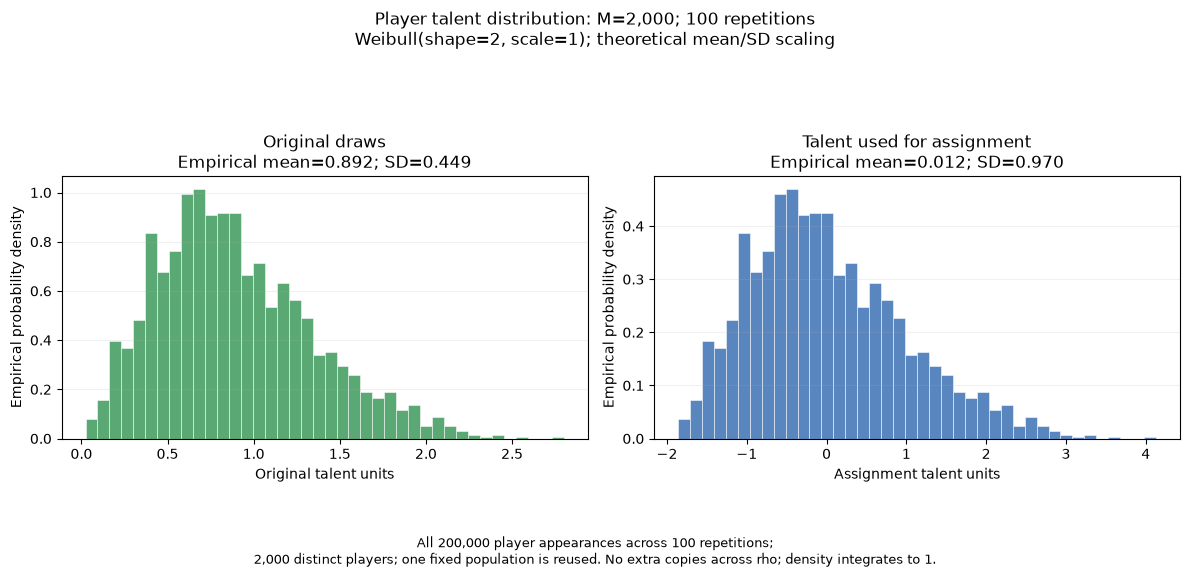

In [5]:
# Visual confirmation before the assignment run, for each unique population/repetition setting.
import matplotlib.pyplot as plt
for scenario in unique_population_scenarios(batch):
    figure = plot_player_distribution(batch, scenario, PROJECT_ROOT, bins=TALENT_HIST_BINS)
    plt.show()
    plt.close(figure)


## Run or resume the selected list

Set RUN_EXPERIMENT=True, then Run All. The runner processes each tuple using
the shared CHANCE_RULE choice (both runs two rules), saves after every division, and reports new versus reused
work. Matching original checkpoints can be read and copied into the new scenario
folder without regenerating assignments. Original results remain untouched.

Only verified complete checkpoints are reused. Interrupted/error state is
preserved. Do not run concurrent notebook/CLI processes against the same scenario.


In [6]:
if RUN_EXPERIMENT:
    run_batch(batch, PROJECT_ROOT)
else:
    print('Execution switch is False. No assignments run by this cell.')


Execution switch is False. No assignments run by this cell.


In [7]:
# Load only selected scenarios that have finished; incomplete ones are reported.
READY_SCENARIOS = ready_scenarios(batch, PROJECT_ROOT)


one_J100_r20_reps100: verified 500 divisions
seats_J100_r20_reps100: running; run/resume before plotting


## Plot every completed scenario

Each tuple gets team-mean and team-variance distribution curves, division sorting
summaries, an actual-roster heatmap of the first assignment, team contender
counts, and self-excluded contender-teammate counts. The rho colors match across
all scenario distribution figures. Variances use ddof=0; shading/error bars show
one repetition SD: assignment variation in same mode; population plus assignment
variation in fresh mode.

A comparison plot puts actual H_sort for all completed selected tuples on the
same axes, with rule and dimensions labeled. A paired-difference plot is added
only for a 'one'/'seats' pair with identical dimensions and repetitions. Shared
player talents, arrival orders and random draws are verified before differencing.

Filenames identify plot type, rule, J, r, repetitions, talent law/scale, rho grid, seeds, and theta
quantile. PNG, SVG and a matching full-parameter JSON sidecar are saved together.
Long lists use a compact grid range/count and unique digest in filenames; exact
values always remain in the JSON. Scientific output stays under results/.


Plotting ('one', 100, 20, 100)
Parameter-named plots saved: /Users/charleslevine/Library/CloudStorage/Dropbox/1-Documents/00- Dissertation/0-Next_Chapter/Code_and_Data/New SQL and PY Code/Cursor Workspace PDE/3-Master_Plan/VECTOR_work/new_VECTOR_work/lg_exploration/results/composition_scenarios/one_J100_r20_reps100/composition-4dea439fdf7a-d39e35e837ee/plots


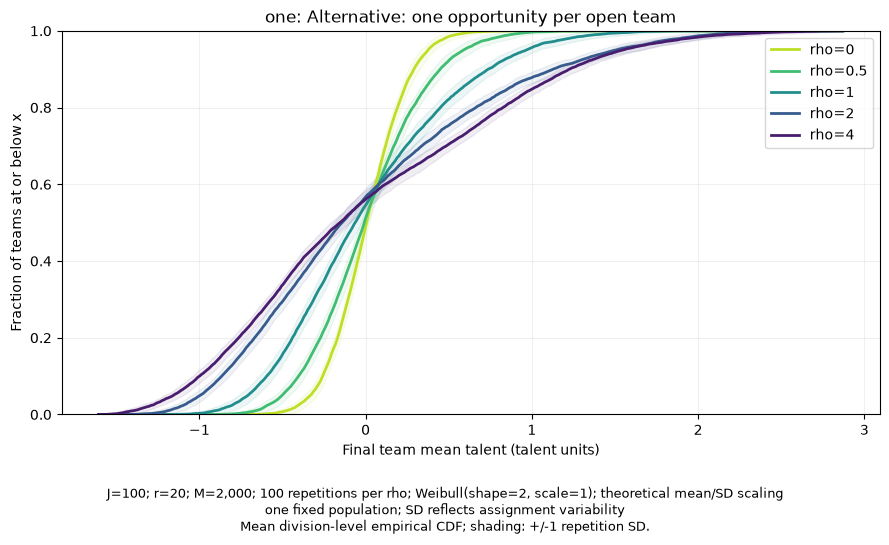

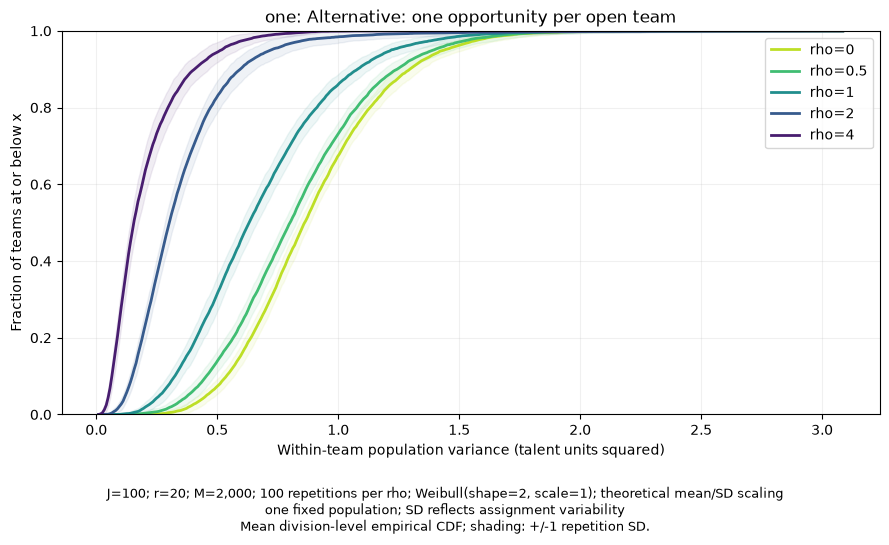

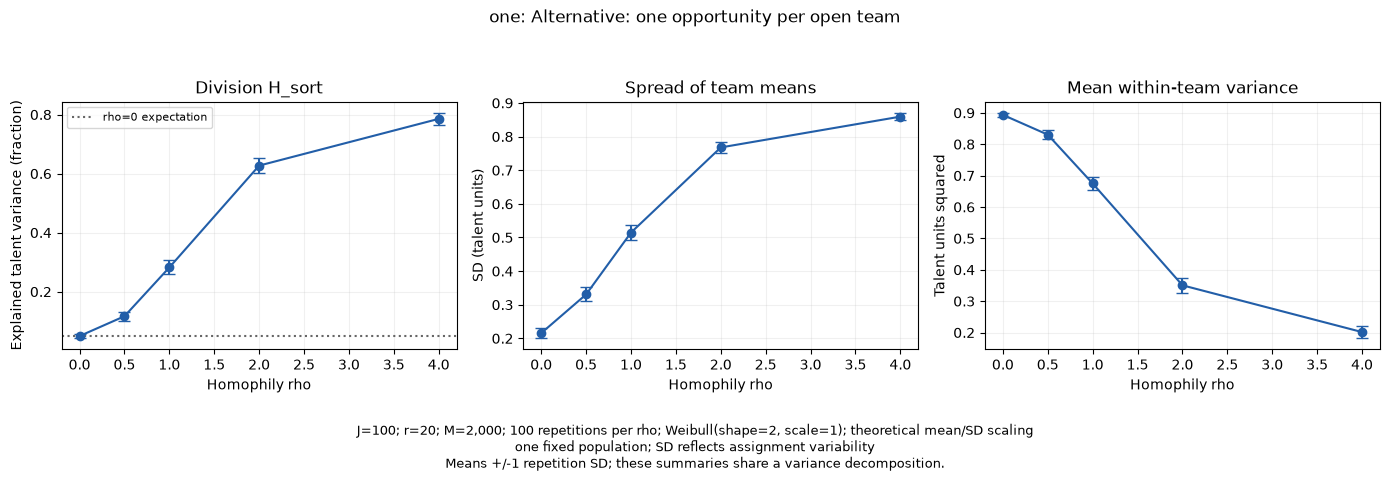

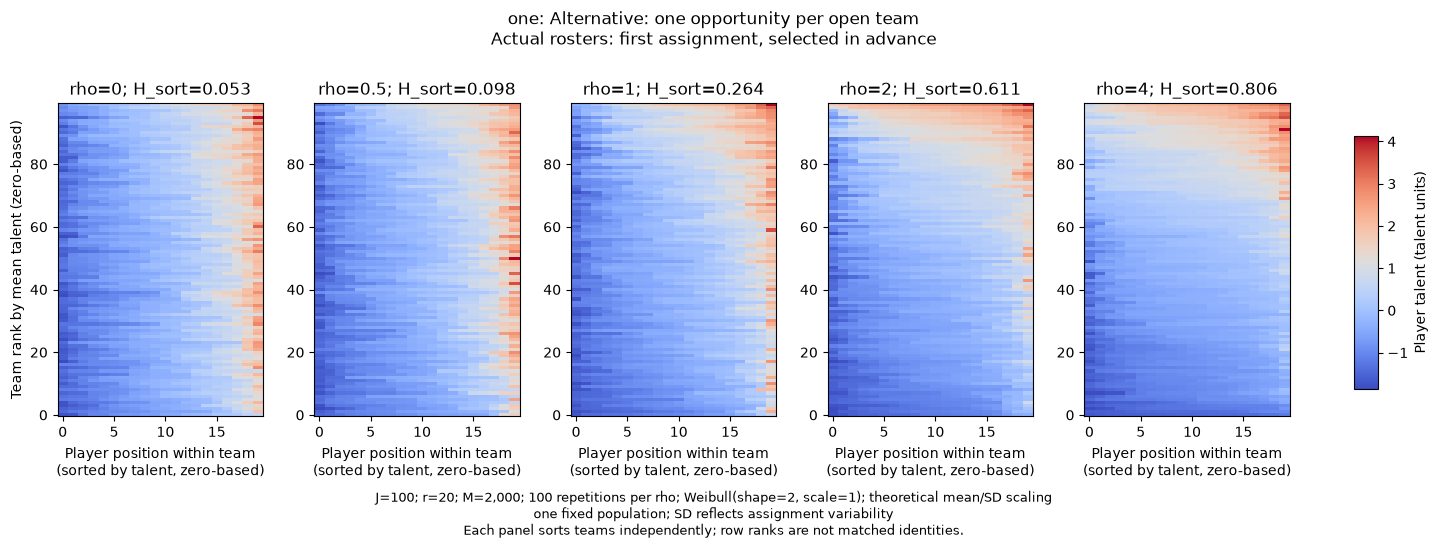

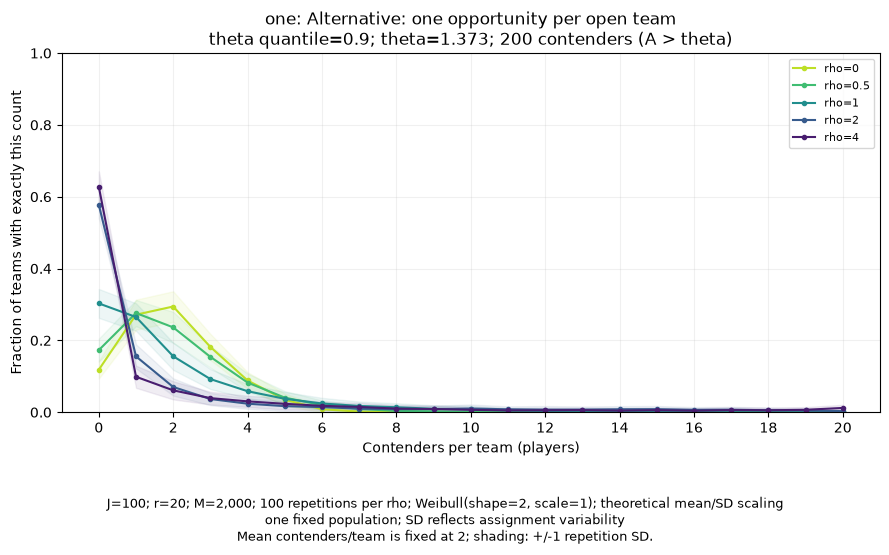

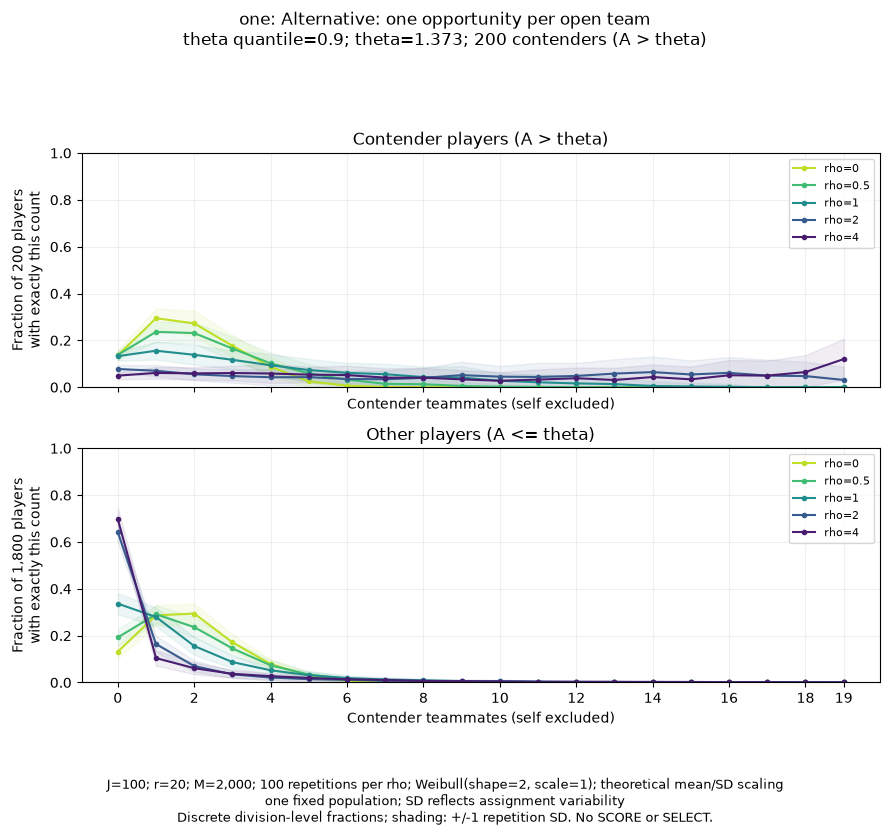

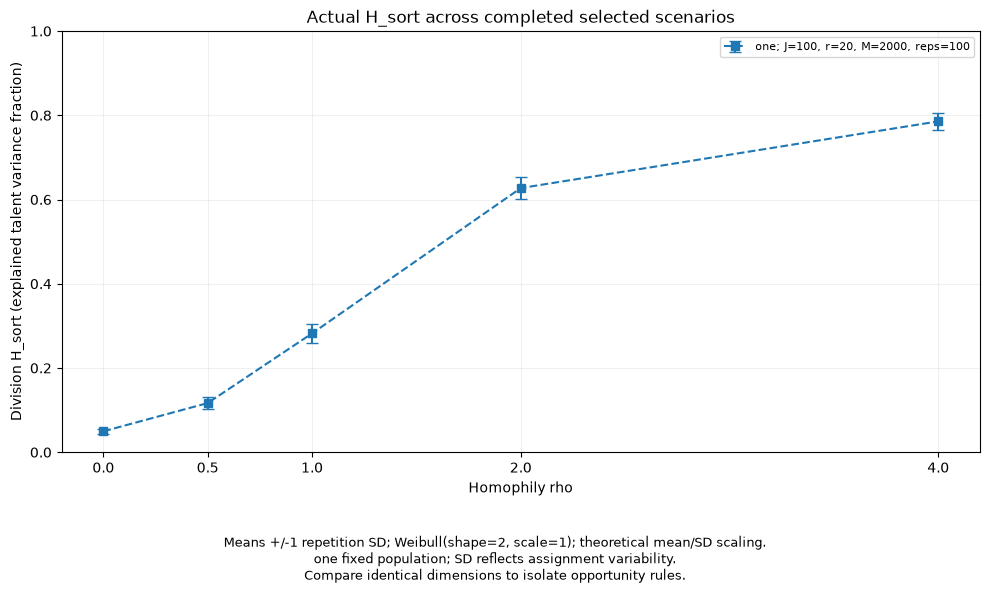

Comparison plots: /Users/charleslevine/Library/CloudStorage/Dropbox/1-Documents/00- Dissertation/0-Next_Chapter/Code_and_Data/New SQL and PY Code/Cursor Workspace PDE/3-Master_Plan/VECTOR_work/new_VECTOR_work/lg_exploration/results/composition_scenarios/comparisons


In [8]:
import matplotlib.pyplot as plt
for item in READY_SCENARIOS:
    print(f'Plotting {item["scenario"].as_tuple()}')
    figures = plot_scenario(batch, item, PROJECT_ROOT)
    print(f'Parameter-named plots saved: {item["directory"] / "plots"}')
    plt.show()
    for figure in figures.values():
        plt.close(figure)

comparison_figures = plot_comparisons(batch, READY_SCENARIOS, PROJECT_ROOT)
if comparison_figures:
    plt.show()
    for figure in comparison_figures.values():
        plt.close(figure)
    print(f'Comparison plots: {PROJECT_ROOT / RESULTS_DIRECTORY / "comparisons"}')


## Interpreting contender counts and sorting

The contender cut is the realized population quantile (linear interpolation),
frozen across rules/rho for each population; A > theta is a contender. It is an exploratory cut,
not a calibrated draft requirement. For focal player i, contender teammates
are the team count minus one if i is a contender. Contenders and other players
are shown separately; a player never counts themselves as a rival.

Within each fixed-roster scenario, mean contenders/team = total contenders/J for each population.
Mean contender teammates across all players = total contenders*(r-1)/M for each population.
Those averages are fixed, while their conditional distributions can change.
No SCORE, SELECT or MLE outcomes are generated.

At rho=0, expected H_sort = (J-1)/(M-1), not necessarily zero. With equal final
sizes, total population variance is the sum of variance of team means and mean
within-team population variance. H_sort, centroid spread and mean within-team
variance therefore describe the same decomposition, rather than independent
pieces of evidence. In same mode, repetitions are not fresh population draws. In fresh mode they are.

Changing r in a tuple changes prescribed equal sizes. Allowing realized roster
sizes to vary is a distinct extension requiring further specification. It follows
this notebook update. See documents/LEO_DECISION_LOG.md for decisions and scope.


## Separate extension: uncapped, variable rosters

Start with **2,000 players and 100 initially empty teams**.
Change total players and team count directly in the complete settings cell below.
Team sizes are outcomes, with no minimum or maximum. Each team remains eligible for
every arrival, with probability proportional to exp(-rho * |A_i - T_j|).
There is no cap, minimum roster, or remaining-seat multiplier. CHANCE_RULE applies
to the fixed-roster section above; this extension uses one opportunity per team.
Empty teams are allowed. Starting centroids default to the realized population
mean (Abar). Set UNCAPPED_INITIAL_CENTROIDS to a number for all teams, or a list
of one value per team. These values are in assignment-talent units. In 'fresh'
mode, the default uses each repetition's own Abar; custom values stay fixed.
Every team starts empty: its first member replaces the imaginary initial signal.
UNCAPPED_TEAM_ATTRACTOR chooses whether later arrivals update the actual-member
mean or actual-member sum. The imaginary value has no permanent weight. Every
uncapped plot displays the initial T_j(0)
values for all teams, including the population preview.

**Charles runs the experiments.** Edit the one uncapped settings cell below,
then execute this section's cells in order. This section loads its own imports
and needs no earlier cells. Its settings are independent of the fixed-roster
section, including the A_i distribution and rho list. RUN_UNCAPPED controls this
section; RUN_EXPERIMENT controls the earlier fixed-roster section. No assignments run while RUN_UNCAPPED=False.
The population-preview cell generates talent draws when you execute it.


In [27]:
# ALL uncapped settings live here. No controls from the earlier section are needed.
# Player count and team count are inputs. Individual team sizes are outcomes.
UNCAPPED_N_PLAYERS = 2000       # Total players to assign; no roster cap.
UNCAPPED_N_TEAMS = 20
UNCAPPED_REPETITIONS = 30        # Assignment repetitions per rho.

# Initial attachment centroid, in the SAME units as talent used for assignment.
UNCAPPED_INITIAL_CENTROIDS = 'population_mean'  # Default: realized Abar for ALL teams.
# Or use one number for every team, e.g. 0.0 or 1.5.
# Or a list of exactly UNCAPPED_N_TEAMS values, in team order (team 1 first).
# Example for three teams: [-1.0, 0.0, 1.0].
# All teams start EMPTY. First arrival replaces its team's imaginary signal;
# the imaginary value then disappears completely.
UNCAPPED_TEAM_ATTRACTOR = 'mean'  # 'mean' or 'sum' after the first real member.
# False: one opportunity/team. True: one base opportunity + one per actual member.
# Every opportunity for a team uses that same team's current attractor.
UNCAPPED_SEATS_OPTION = True

# A_i distribution and scale, independent of the fixed-roster section above.
UNCAPPED_TALENT_DISTRIBUTION = 'uniform'  # 'normal', 'uniform', 'beta', or 'weibull'
UNCAPPED_WEIBULL_SHAPE = 2.0             # Native Weibull scale is 1.
UNCAPPED_TALENT_SCALE = 'theoretical_mean_sd'  # Or 'original'.
UNCAPPED_TALENT_HIST_BINS = 40

UNCAPPED_RHO_VALUES = [0.0, 0.5, 1.0, 2.0, 4.0]  # Include zero as the baseline.
UNCAPPED_POPULATION_MODE = 'same'  # Default: reuse players. 'fresh': redraw each repetition.
UNCAPPED_POPULATION_SEED = 6102026
UNCAPPED_ASSIGNMENT_SEED = 6102027
UNCAPPED_THETA_QUANTILE = 0.9
UNCAPPED_RESULTS_DIRECTORY = 'results/uncapped_rosters'
RUN_UNCAPPED = True             # Charles switches this on to run/resume.

# Temporary display filter; changing this does not require new assignments.
UNCAPPED_ROSTER_PLOTS_ONLY = True  # True: A_i + roster views. False: all plots.
# Actual team sizes for the printed list and circles (1 = first repetition).
UNCAPPED_ROSTER_DISPLAY_REPETITION = 1


In [28]:
# Load fresh helpers and save the applied settings; no scientific execution here.
from pathlib import Path
import sys
import importlib
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'README_START_HERE.md').is_file():
    raise RuntimeError('Start Jupyter in lg_exploration/ or its notebooks/ folder.')
if str(PROJECT_ROOT / 'code') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'code'))
importlib.invalidate_caches()
import lg_composition.talent as _talent
import lg_composition.uncapped as _uncapped
import lg_composition.uncapped_plots as _uncapped_plots
# Reload dependencies first: otherwise a live kernel can label a new law while
# retaining an older draw_population function.
for _module in (_talent, _uncapped, _uncapped_plots):
    importlib.reload(_module)
from lg_composition.uncapped import UncappedSettings, export_settings, run_uncapped
from lg_composition.uncapped_plots import plot_population_preview, plot_uncapped

uncapped_settings = UncappedSettings.from_dict({
    'n_players': UNCAPPED_N_PLAYERS,
    'n_teams': UNCAPPED_N_TEAMS,
    'team_attractor': UNCAPPED_TEAM_ATTRACTOR,
    'seats_option': UNCAPPED_SEATS_OPTION,
    'initial_centroids': UNCAPPED_INITIAL_CENTROIDS,
    'assignment_repetitions': UNCAPPED_REPETITIONS,
    'rhos': UNCAPPED_RHO_VALUES,
    'talent_distribution': UNCAPPED_TALENT_DISTRIBUTION,
    'weibull_shape': UNCAPPED_WEIBULL_SHAPE,
    'talent_scale': UNCAPPED_TALENT_SCALE,
    'population_mode': UNCAPPED_POPULATION_MODE,
    'population_seed': UNCAPPED_POPULATION_SEED,
    'assignment_seed': UNCAPPED_ASSIGNMENT_SEED,
    'theta_quantile': UNCAPPED_THETA_QUANTILE,
    'results_directory': UNCAPPED_RESULTS_DIRECTORY,
})
uncapped_snapshot = export_settings(uncapped_settings, PROJECT_ROOT)
print(f'Generated settings snapshot: {uncapped_snapshot}')
print(f'Uncapped divisions: {uncapped_settings.unit_count}')
print(f'M={UNCAPPED_N_PLAYERS:,}; J={UNCAPPED_N_TEAMS:,}; '
      f'fixed mean roster size M/J={UNCAPPED_N_PLAYERS / UNCAPPED_N_TEAMS:g}')
print('Individual team sizes are free to vary, including zero.')
print(f'Team attachment attractor: {uncapped_settings.team_attractor}')
print(f'Opportunities: {"1 + actual members" if uncapped_settings.seats_option else "one per team"}')
print(f'Initial team centroids: {uncapped_settings.initial_centroids}')


Generated settings snapshot: /Users/charleslevine/Library/CloudStorage/Dropbox/1-Documents/00- Dissertation/0-Next_Chapter/Code_and_Data/New SQL and PY Code/Cursor Workspace PDE/3-Master_Plan/VECTOR_work/new_VECTOR_work/lg_exploration/settings/uncapped_rosters.json
Uncapped divisions: 150
M=2,000; J=20; fixed mean roster size M/J=100
Individual team sizes are free to vary, including zero.
Team attachment attractor: mean
Initial team centroids: population_mean


### First: check the player distribution

One preview for this uncapped setting, pooling all repetitions without duplicating
for rho. 'same' repeats one fixed population; 'fresh' uses a new population per
repetition. This cell draws talent and saves the preview; it does not assign teams.


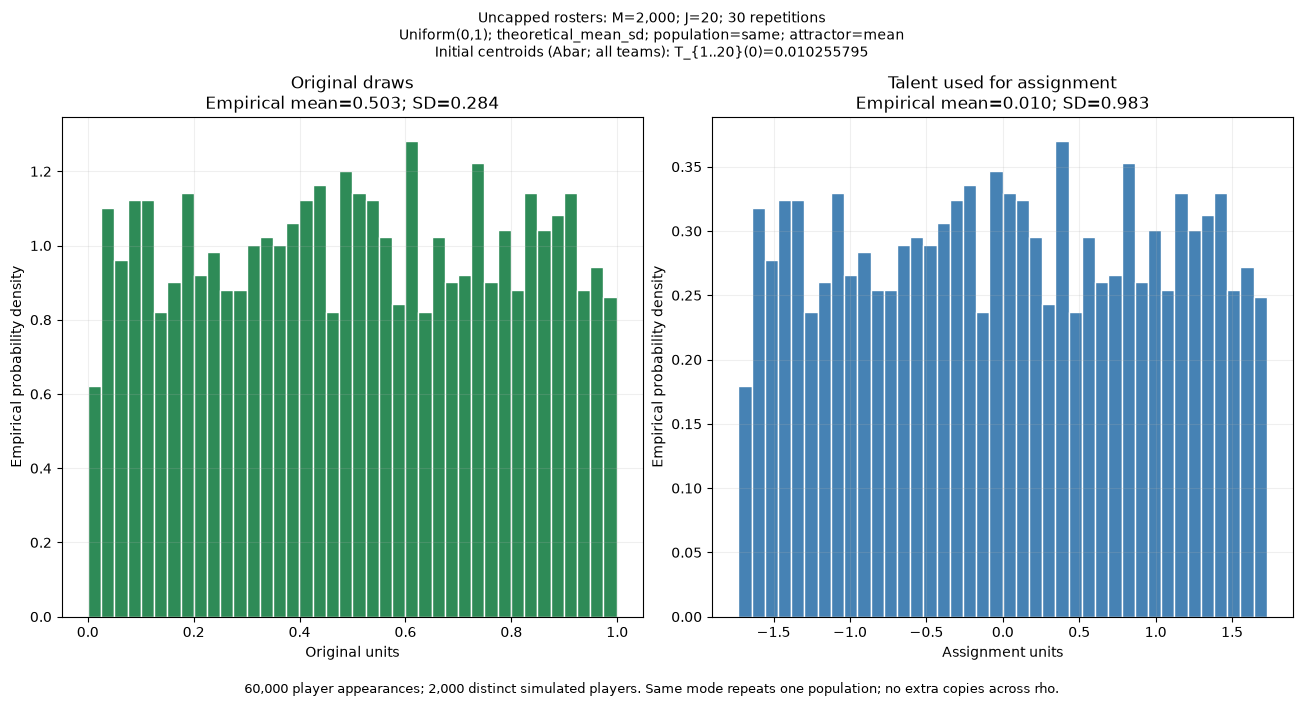

In [29]:
import matplotlib.pyplot as plt
# Always show A_i, including in roster-only mode; refresh plotting helpers here.
import importlib
import lg_composition.talent as _talent
import lg_composition.uncapped as _uncapped
import lg_composition.uncapped_plots as _uncapped_plots
# Dependency order matters in a live notebook kernel.
for _module in (_talent, _uncapped, _uncapped_plots):
    importlib.reload(_module)
from lg_composition.uncapped_plots import plot_population_preview
figure = plot_population_preview(uncapped_settings, PROJECT_ROOT, bins=UNCAPPED_TALENT_HIST_BINS)
plt.show()
plt.close(figure)


In [30]:
# Explicit execution gate: only Charles starts the assignment experiments.
if RUN_UNCAPPED:
    uncapped_directory = run_uncapped(uncapped_settings, PROJECT_ROOT)
else:
    print('RUN_UNCAPPED=False: no assignments executed. Existing completed results can be plotted below.')


Uncapped 1/150; rho=0, repetition=1; 1 new, 0 reused; 0.0s
Uncapped 2/150; rho=0.5, repetition=1; 2 new, 0 reused; 0.1s
Uncapped 3/150; rho=1, repetition=1; 3 new, 0 reused; 0.1s
Uncapped 4/150; rho=2, repetition=1; 4 new, 0 reused; 0.1s
Uncapped 5/150; rho=4, repetition=1; 5 new, 0 reused; 0.1s
Uncapped 6/150; rho=0, repetition=2; 6 new, 0 reused; 0.2s
Uncapped 7/150; rho=0.5, repetition=2; 7 new, 0 reused; 0.2s
Uncapped 8/150; rho=1, repetition=2; 8 new, 0 reused; 0.2s
Uncapped 9/150; rho=2, repetition=2; 9 new, 0 reused; 0.2s
Uncapped 10/150; rho=4, repetition=2; 10 new, 0 reused; 0.3s
Uncapped 11/150; rho=0, repetition=3; 11 new, 0 reused; 0.3s
Uncapped 12/150; rho=0.5, repetition=3; 12 new, 0 reused; 0.3s
Uncapped 13/150; rho=1, repetition=3; 13 new, 0 reused; 0.3s
Uncapped 14/150; rho=2, repetition=3; 14 new, 0 reused; 0.4s
Uncapped 15/150; rho=4, repetition=3; 15 new, 0 reused; 0.4s
Uncapped 16/150; rho=0, repetition=4; 16 new, 0 reused; 0.4s
Uncapped 17/150; rho=0.5, repetition

### Resulting team-size distributions

The first figure shows the **actual roster-size probabilities** and cumulative
fractions, one color per rho, including empty teams. Each repetition contributes
one distribution over all J teams. The dashed reference is the exact rho=0
Binomial(M, 1/J) marginal distribution, calculated mathematically.
The dotted M/J line marks the fixed average, not a required roster size.

Additional figures show empty-team counts, largest rosters and roster-size SD;
player-weighted H_sort and variance components; occupied-team talent distributions;
and contender-count distributions. Shading/error bars indicate ±1 repetition SD,
not uncertainty bounds on the mean. With one repetition these have zero width.
PNG/SVG names identify parameters; JSON sidecars retain every exact value.
A CSV also saves roster-size frequencies separately for every rho and repetition.

UNCAPPED_ROSTER_PLOTS_ONLY=True keeps the A_i population preview and the
roster-size probability and cumulative distributions, printed descending sizes,
and filled-circle roster view. It skips the other team diagnostics. Set it to False to restore all plots.
Rerun the settings, validation/import, and plot cells after changing the switch;
completed assignments are reused and need not be rerun. Existing plot files stay
on disk. Clearing old cell output removes plots from a previous display.

After the distributions, a plain-text list prints (team size, team mean) tuples,
sorted by descending size, separately for each rho. Means use assignment-talent
units and three decimal places; empty teams show (0, undefined). The next large figure shows one filled
circle per occupied team, with area proportional to membership and the same
scale across rho panels. Empty teams are counted in each panel's title. Circle
positions are a display grid, ordered largest to smallest, not model coordinates.
A second, otherwise identical circle figure uses area proportional to the absolute
team mean. Red means positive, blue negative, and gray zero; teams are ordered
by descending absolute mean. Empty teams have undefined means and no circles.
The final circle figure shows only the highest rho. Circle area represents team
size, while a symmetric, zero-centered color scale represents the team mean:
darker red is more positive, darker blue more negative, and near-white near zero.
When UNCAPPED_N_TEAMS is 15 or less, an additional wide figure reconstructs
the observed mean of every team after each assignment round, with one colored
line per team and one panel per rho. Lines begin at each team's first real member.
Both use UNCAPPED_ROSTER_DISPLAY_REPETITION (1 by default), one actual division
per rho. The distribution curves above continue to summarize all repetitions.
Change the repetition in the settings cell and rerun settings and plotting cells
to inspect another existing assignment. No new assignments are needed.


Parameter-named plots: /Users/charleslevine/Library/CloudStorage/Dropbox/1-Documents/00- Dissertation/0-Next_Chapter/Code_and_Data/New SQL and PY Code/Cursor Workspace PDE/3-Master_Plan/VECTOR_work/new_VECTOR_work/lg_exploration/results/uncapped_rosters/uncapped-3c973d3cb8ed-106dc0535052/plots
Roster-size frequencies: /Users/charleslevine/Library/CloudStorage/Dropbox/1-Documents/00- Dissertation/0-Next_Chapter/Code_and_Data/New SQL and PY Code/Cursor Workspace PDE/3-Master_Plan/VECTOR_work/new_VECTOR_work/lg_exploration/results/uncapped_rosters/uncapped-3c973d3cb8ed-106dc0535052/roster_size_distributions.csv


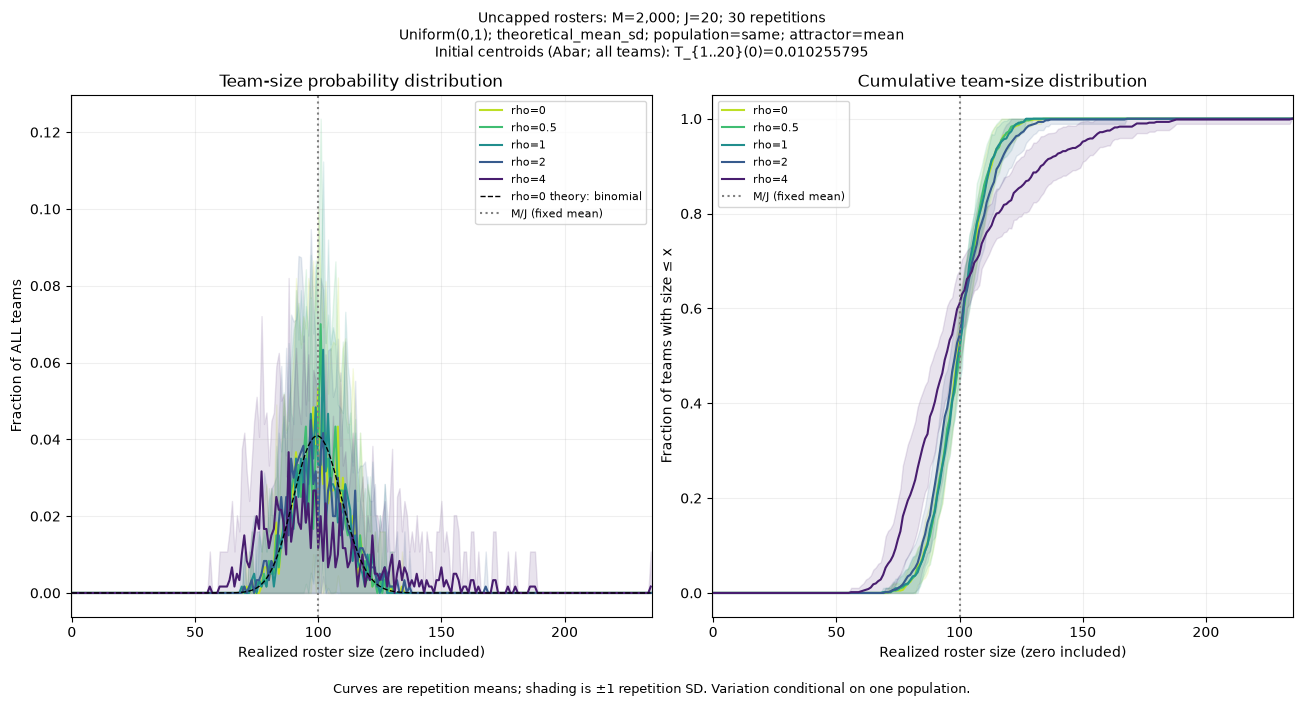

Descending (team size, team mean) — repetition 1 (one actual division per rho; means in assignment units, to 3 decimals; empty-team means are undefined):

rho=0; largest=120; empty teams=0
[(120, 0.093), (117, 0.041), (114, -0.070), (107, 0.036), (106, 0.122), (106, 0.172), (106, 0.077), (104,
-0.056), (103, -0.141), (101, 0.032), (101, 0.001), (100, 0.023), (98, -0.123), (96, 0.077), (90, 0.008), (90,
0.147), (86, -0.022), (86, -0.049), (86, -0.032), (83, -0.197)]

rho=0.5; largest=116; empty teams=0
[(116, -0.027), (114, -0.021), (114, 0.026), (112, 0.171), (108, 0.068), (108, -0.051), (107, 0.029), (106,
-0.150), (101, -0.015), (100, 0.238), (97, -0.303), (95, 0.310), (95, -0.036), (92, -0.237), (91, -0.074),
(90, -0.258), (90, 0.362), (90, 0.057), (89, 0.104), (85, 0.007)]

rho=1; largest=113; empty teams=0
[(113, 0.879), (111, 0.157), (110, 0.404), (108, 0.063), (107, 0.310), (104, -0.277), (104, 0.277), (103,
-0.373), (103, -0.464), (102, 0.300), (102, -0.361), (101, 0.044), (98,

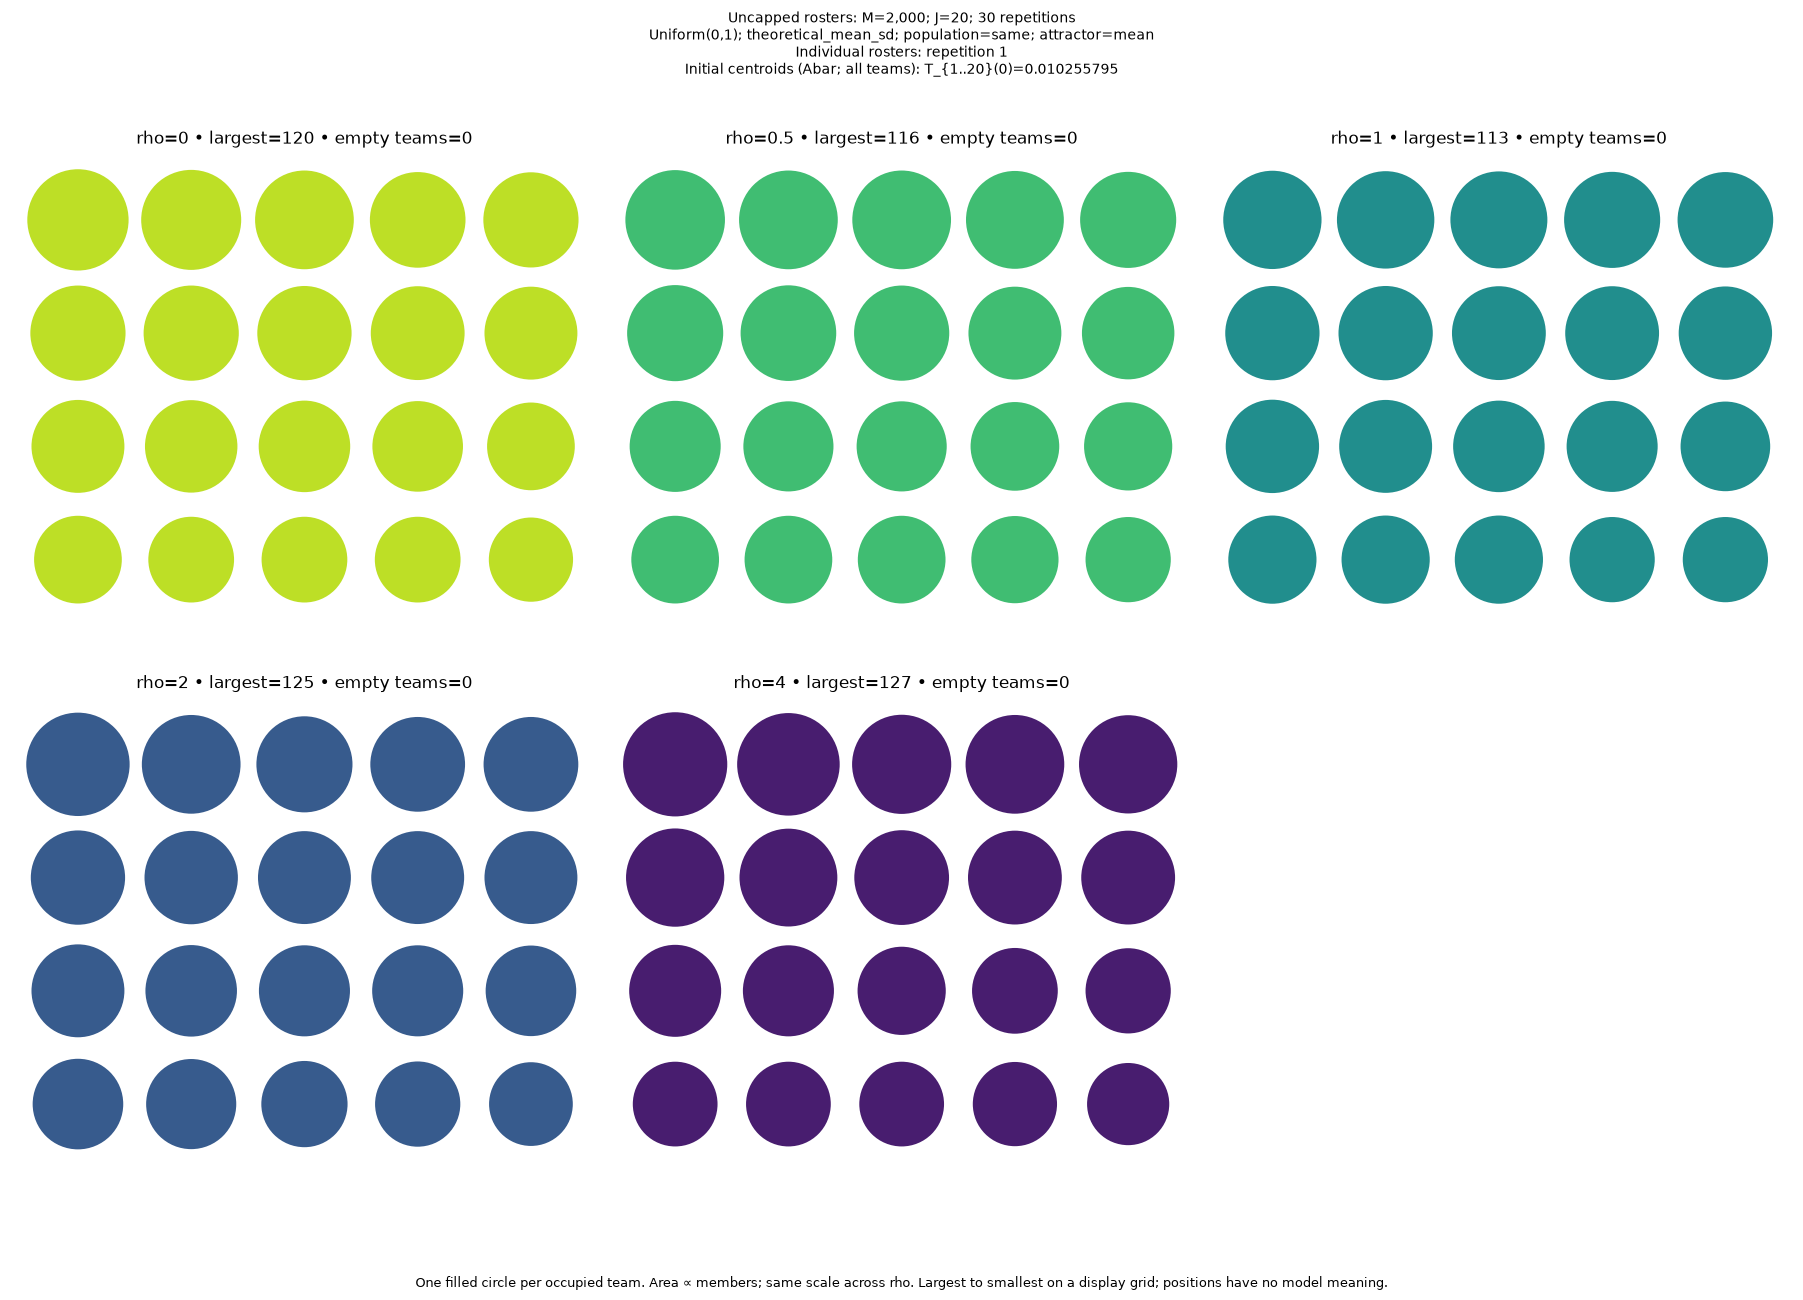

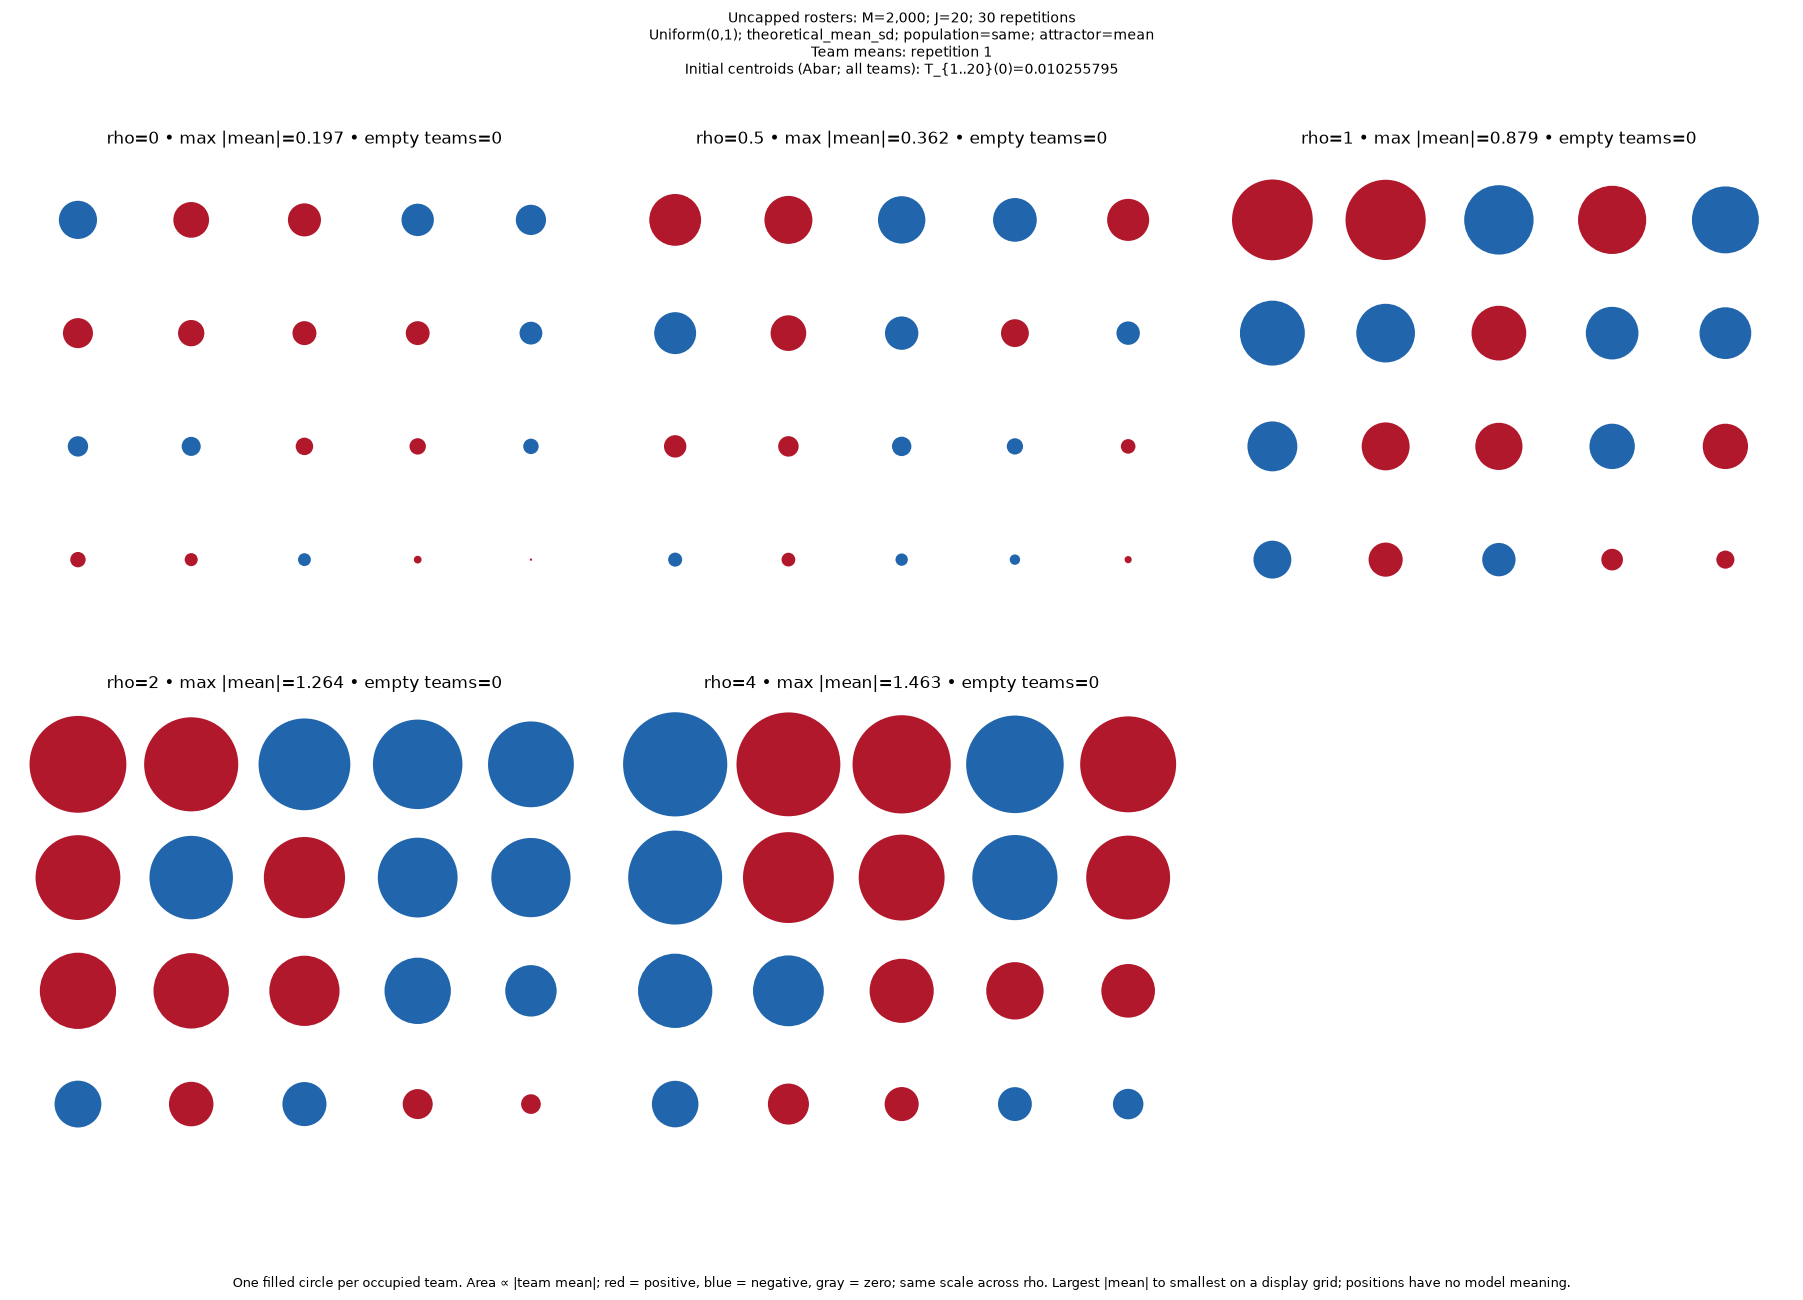

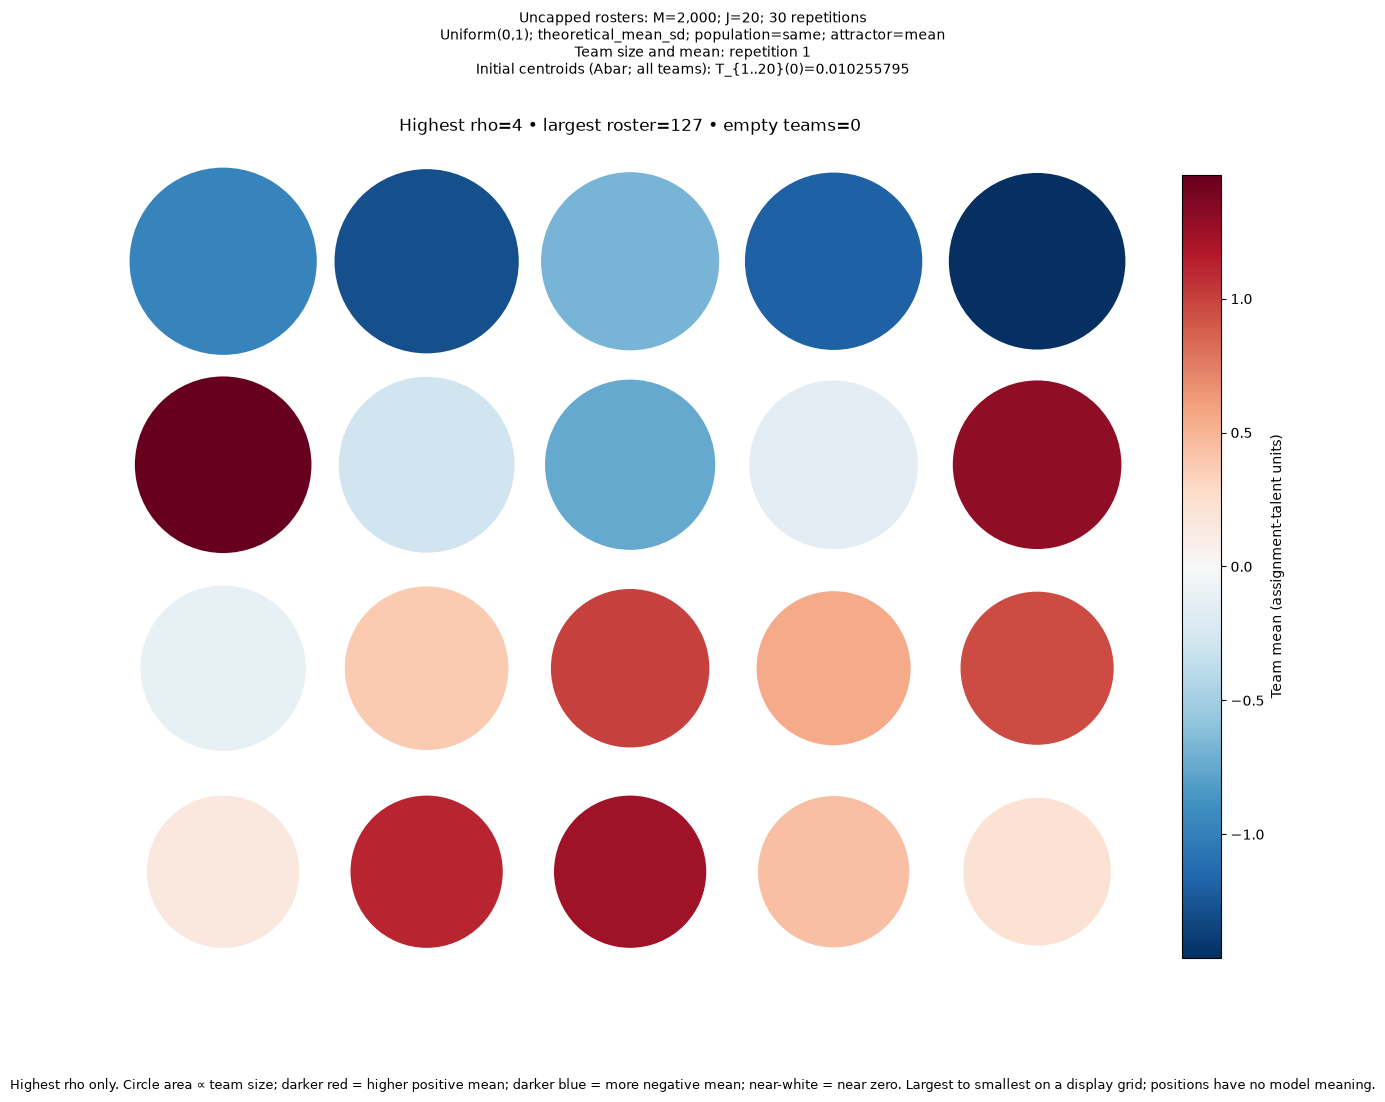

In [31]:
import matplotlib.pyplot as plt
from IPython.display import display
# Refresh plot helpers here so rerunning this cell picks up layout/style edits.
import importlib
import lg_composition.uncapped_plots as _uncapped_plots
importlib.reload(_uncapped_plots)
from lg_composition.uncapped_plots import plot_uncapped
# Plot only verified, completed checkpoints. This cell never assigns players.
try:
    uncapped_figures, uncapped_directory = plot_uncapped(uncapped_settings, PROJECT_ROOT,
                                                         roster_only=UNCAPPED_ROSTER_PLOTS_ONLY,
                                                         roster_repetition=UNCAPPED_ROSTER_DISPLAY_REPETITION-1)
except FileNotFoundError as error:
    print(error)
else:
    print(f'Parameter-named plots: {uncapped_directory / "plots"}')
    print(f'Roster-size frequencies: {uncapped_directory / "roster_size_distributions.csv"}')
    for metric, figure in uncapped_figures.items():
        display(figure)
        plt.close(figure)
        if metric == 'roster_size_distribution':
            # Plain notebook output after the distribution, not written on a plot.
            ranked_file = uncapped_directory / f'ranked_team_sizes_rep-{UNCAPPED_ROSTER_DISPLAY_REPETITION:03d}.txt'
            print(ranked_file.read_text())


### Reading the uncapped extension

Means and variances of empty teams are undefined and are excluded from talent
CDFs; their zeros remain in every roster-size distribution. Singleton variance
is zero (ddof=0). Empty-team attachment signals retain their chosen initial centroid,
which is not reported as an observed team mean. All plots identify initial T_j(0);
fresh mode displays only the chosen target (Abar or your specified values),
without listing each repetition's realized Abar. Exact per-team starting values
are retained in checkpoints and plot JSON sidecars.

Unequal team sizes require player-weighted variance components:
B = sum_j n_j (mean_j - population_mean)^2 / M,
W = sum_j n_j variance_j / M, and H_sort = B / variance(A).
Then B + W = variance(A). At rho=0, expected H_sort equals
(expected occupied teams - 1)/(M - 1); random grouping already produces some
between-team variation. This is a separate uncapped model, not fixed-roster LG.

Contender counts still use strict A > theta and exclude self for focal players.
Mean contenders per team is total contenders/J. With unequal rosters, the mean
number of contender teammates across all players can vary because
sum_i contender_teammates_i = sum_j contenders_j * (n_j - 1).
